# Training an SFNO on the Spherical Shallow Water Equations in Neuromancer

This notebook mirrors the Part 4 FNO workflow, but uses a Spherical Fourier Neural Operator (SFNO) from `neuralop` wrapped in a Neuromancer `Node`.

We will:
1. Load and visualize the spherical SWE dataset
2. Wrap the data in `neuromancer.dataset.DictDataset`
3. Train an SFNO with an L2 loss (`LpLoss` with sum reduction)
4. Evaluate and visualize predictions at multiple resolutions


## Problem Description

The spherical shallow water equations (SWE) model the evolution of a thin fluid layer on the sphere. The state includes two horizontal velocity components and the fluid height, which makes this dataset a compact proxy for geophysical dynamics on a curved domain.


## Surrogate model problem

We learn an operator that maps the current SWE state on a spherical grid to the next state. The SFNO extends the Fourier Neural Operator to spherical harmonics, making it well suited for global geophysical data.


## Install (Colab only)

Skip this step when running locally.


In [1]:
# !pip install neuromancer
# !pip install neuralop


## Imports


In [ ]:
import warnings

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Load the spherical shallow water dataset

We train on a low resolution to keep the example lightweight, then evaluate at multiple resolutions.


In [4]:
from neuralop.data.datasets import load_spherical_swe

# Dataset configuration
n_train = 200
batch_size_train = 32
train_resolution = (32, 64)

n_tests = [40, 40]
test_resolutions = [(32, 64), (64, 128)]
test_batch_sizes = [40, 40]

train_loader, test_loaders = load_spherical_swe(
    n_train=n_train,
    batch_size=batch_size_train,
    train_resolution=train_resolution,
    test_resolutions=test_resolutions,
    n_tests=n_tests,
    test_batch_sizes=test_batch_sizes,
)

train_dataset = train_loader.dataset
print(f"Train dataset size: {len(train_dataset)}")


Loading train dataloader at resolution (32, 64) with 200 samples and batch-size=32
Loading test dataloader at resolution (32, 64) with 40 samples and batch-size=40
Loading test dataloader at resolution (64, 128) with 40 samples and batch-size=40
Train dataset size: 200


### Inspect dataset samples


In [5]:
sample = train_dataset[0]
print(sample.keys())
print("x shape:", sample["x"].shape)
print("y shape:", sample["y"].shape)


dict_keys(['x', 'y'])
x shape: torch.Size([3, 32, 64])
y shape: torch.Size([3, 32, 64])


### Helper utilities for spherical SWE data


In [6]:
def unpack_swe_sample(sample):
    # Return (x, y) as [C, H, W] tensors.
    x = sample["x"]
    y = sample["y"]
    if y.ndim == 4:
        y = y[0]
    if x.ndim == 4:
        x = x[0]
    return x.float(), y.float()


def stack_swe_dataset(dataset):
    # Stack the full dataset into [N, C, H, W] tensors.
    xs, ys = [], []
    for i in range(len(dataset)):
        x, y = unpack_swe_sample(dataset[i])
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)


def plot_swe_fields(x, y, title="Spherical SWE sample"):
    # Visualize input and target channels side by side.
    x = x.detach().cpu()
    y = y.detach().cpu()
    if x.ndim == 2:
        x = x.unsqueeze(0)
    if y.ndim == 2:
        y = y.unsqueeze(0)

    n_channels = min(x.shape[0], y.shape[0], 3)
    field_names = ["u", "v", "h"]

    fig = plt.figure(figsize=(4 * n_channels, 6))
    for i in range(n_channels):
        ax = fig.add_subplot(2, n_channels, i + 1)
        ax.imshow(x[i])
        ax.set_title(f"Input {field_names[i] if i < len(field_names) else f'ch{i}'}")
        ax.set_xticks([])
        ax.set_yticks([])

        ax = fig.add_subplot(2, n_channels, n_channels + i + 1)
        ax.imshow(y[i])
        ax.set_title(f"Target {field_names[i] if i < len(field_names) else f'ch{i}'}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.show()


def plot_prediction(x, y, y_pred, title, channel=0):
    # Plot a single channel prediction against ground truth.
    x = x.detach().cpu()
    y = y.detach().cpu()
    y_pred = y_pred.detach().cpu()

    if x.ndim == 2:
        x = x.unsqueeze(0)
    if y.ndim == 2:
        y = y.unsqueeze(0)
    if y_pred.ndim == 2:
        y_pred = y_pred.unsqueeze(0)

    vmin = y[channel].min().item()
    vmax = y[channel].max().item()
    l2_error = torch.norm(y_pred[channel] - y[channel]).item()

    fig = plt.figure(figsize=(12, 4))
    ax = fig.add_subplot(1, 3, 1)
    ax.imshow(x[channel])
    ax.set_title("Input")
    ax = fig.add_subplot(1, 3, 2)
    ax.imshow(y[channel], vmin=vmin, vmax=vmax)
    ax.set_title("Ground truth")
    ax = fig.add_subplot(1, 3, 3)
    ax.imshow(y_pred[channel], vmin=vmin, vmax=vmax)
    ax.set_title(f"SFNO prediction (L2 error: {l2_error:.3e})")

    for ax in fig.axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.show()


### Visualize a training sample


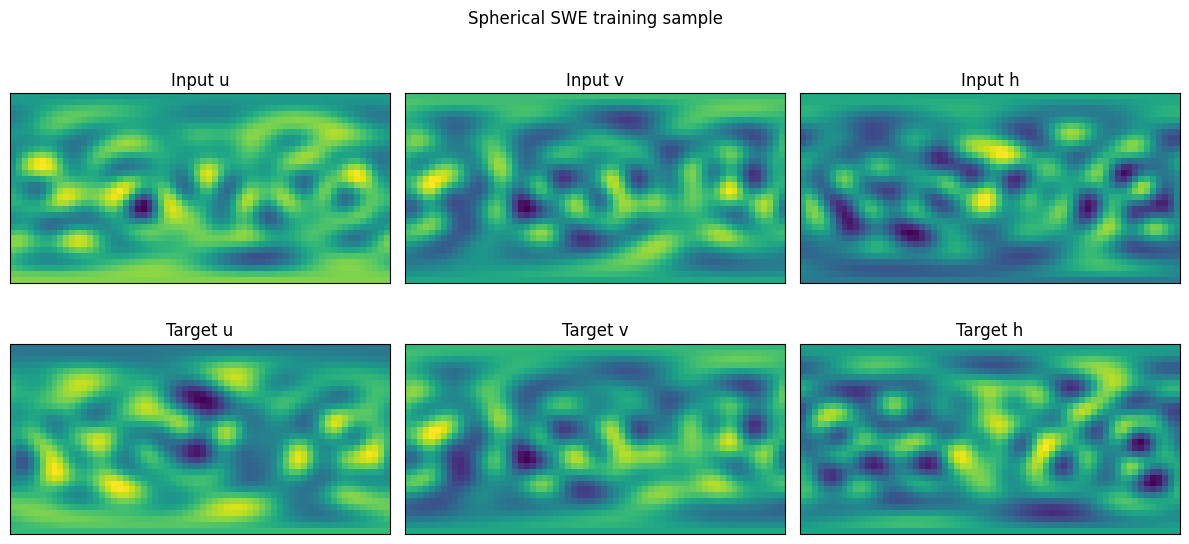

In [7]:
vis_x, vis_y = unpack_swe_sample(train_dataset[0])
plot_swe_fields(vis_x, vis_y, title="Spherical SWE training sample")


### Create Neuromancer datasets for SFNO


In [8]:
from torch.utils.data import DataLoader
from neuromancer.dataset import DictDataset

# Training data
x_train, y_train = stack_swe_dataset(train_dataset)
x_train = x_train.to(device)
y_train = y_train.to(device)

train_ds = DictDataset({"x_grid": x_train, "y_grid": y_train}, name="train")
train_loader_nm = DataLoader(
    train_ds,
    batch_size=batch_size_train,
    shuffle=True,
    collate_fn=train_ds.collate_fn,
)

# Testing data at multiple resolutions
test_ds_by_res = {}
for res in test_resolutions:
    test_dataset = test_loaders[res].dataset
    x_test, y_test = stack_swe_dataset(test_dataset)
    x_test = x_test.to(device)
    y_test = y_test.to(device)
    test_ds_by_res[res] = DictDataset(
        {"x_grid": x_test, "y_grid": y_test}, name=f"test_{res[0]}x{res[1]}"
    )


### Dimensionality checks


In [9]:
print("Train x:", train_ds.datadict["x_grid"].shape)
print("Train y:", train_ds.datadict["y_grid"].shape)
for res, ds in test_ds_by_res.items():
    print(f"Test {res} x:", ds.datadict["x_grid"].shape)
    print(f"Test {res} y:", ds.datadict["y_grid"].shape)


Train x: torch.Size([200, 3, 32, 64])
Train y: torch.Size([200, 3, 32, 64])
Test (32, 64) x: torch.Size([40, 3, 32, 64])
Test (32, 64) y: torch.Size([40, 3, 32, 64])
Test (64, 128) x: torch.Size([40, 3, 64, 128])
Test (64, 128) y: torch.Size([40, 3, 64, 128])


### Create the SFNO model


In [10]:
from neuromancer.modules.operators import SFNO
from neuralop.utils import count_model_params

in_channels = x_train.shape[1]
out_channels = y_train.shape[1]
n_modes = (train_resolution[0] // 2, train_resolution[1] // 2)

sfno_model = SFNO(
    n_modes=n_modes,
    in_channels=in_channels,
    out_channels=out_channels,
    hidden_channels=64,
    domain_padding=[0.05, 0.05],
    n_layers=2,
).to(device)

n_params = count_model_params(sfno_model)
print(f"Our model has {n_params} parameters.")


Our model has 296707 parameters.


### Wrap SFNO in a Neuromancer Node


In [11]:
from neuromancer.system import Node

sfno_node = Node(sfno_model, ["x_grid"], ["y_hat"], name="sfno_model")
print("symbolic inputs:", sfno_node.input_keys)
print("symbolic outputs:", sfno_node.output_keys)

# Forward pass sanity check
with torch.no_grad():
    sample_out = sfno_node({"x_grid": x_train[:1]})
print("SFNO output shape:", sample_out["y_hat"].shape)


symbolic inputs: ['x_grid']
symbolic outputs: ['y_hat']
SFNO output shape: torch.Size([1, 3, 32, 64])


### L2 loss and Neuromancer problem


In [12]:
from neuromancer.constraint import Loss
from neuromancer.modules.operators import LpLoss

# L2 loss with sum reduction for spherical data
l2loss = LpLoss(d=2, p=2, reduction="sum")

l2_obj = Loss(
    ["y_hat", "y_grid"],
    lambda yhat, y: l2loss(yhat, y),
    name="l2_loss",
)

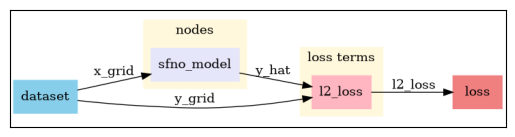

In [13]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

loss = PenaltyLoss([l2_obj], [])
problem = Problem(nodes=[sfno_node], loss=loss)
problem.show()

### Train the SFNO (Neuromancer Trainer)


In [14]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.AdamW(problem.parameters(), lr=5e-3, weight_decay=1e-4)
epochs = 100

trainer = Trainer(
    problem.to(device),
    train_loader_nm,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=5,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

best_model = trainer.train()
problem.load_state_dict(best_model)


epoch: 0  train_loss: 0.7507240176200867
epoch: 5  train_loss: 0.26715052127838135
epoch: 10  train_loss: 0.1920524388551712
epoch: 15  train_loss: 0.15459787845611572
epoch: 20  train_loss: 0.12375575304031372
epoch: 25  train_loss: 0.1097889393568039
epoch: 30  train_loss: 0.09441495686769485
epoch: 35  train_loss: 0.08924294263124466
epoch: 40  train_loss: 0.08329175412654877
epoch: 45  train_loss: 0.07928574085235596
epoch: 50  train_loss: 0.0707399770617485
epoch: 55  train_loss: 0.07104728370904922
epoch: 60  train_loss: 0.06615372002124786
epoch: 65  train_loss: 0.0621112622320652
epoch: 70  train_loss: 0.06421899795532227
epoch: 75  train_loss: 0.05840538069605827
epoch: 80  train_loss: 0.057623524218797684
epoch: 85  train_loss: 0.05826960504055023
epoch: 90  train_loss: 0.05570705607533455
epoch: 95  train_loss: 0.053978003561496735


<All keys matched successfully>

### Visualize SFNO predictions


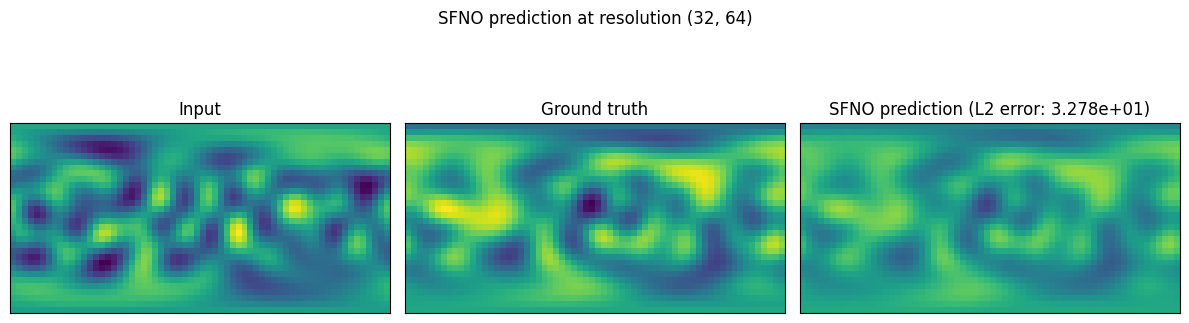

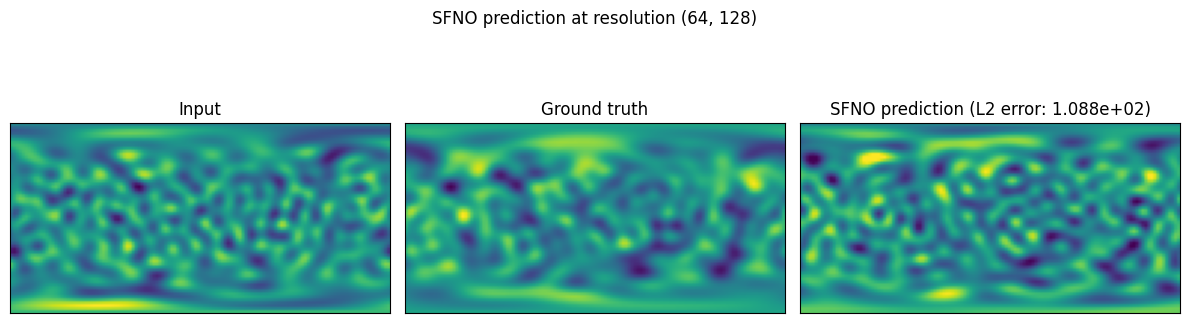

In [15]:
sfno_eval = problem.nodes[0].to(device)

for res, test_ds in test_ds_by_res.items():
    x_test = test_ds.datadict["x_grid"]
    y_test = test_ds.datadict["y_grid"]
    with torch.no_grad():
        preds = sfno_eval({"x_grid": x_test})["y_hat"]
    plot_prediction(
        x_test[0],
        y_test[0],
        preds[0],
        title=f"SFNO prediction at resolution {res}",
        channel=0,
    )
